# Präsentation: Task1, Team 3

### Benjamin Gielczynski, David von Rüden, Tim Giese, Victor Domke, Simon Brockhoff

## 1. Der Code:
### 1.1 dataframe_manager.py
    - Lesen der Rohdaten der Signale aus data-Ordner
    - ordnen im DataFrame.

In [30]:
import pandas as pd     # für Dataframe
import os               # für das durchsuchen der ordner
import glob             # für das durchsuchen der ordner
import soundfile as sf  # für das Laden des Signals

class DataFrameManager:
    """
    DataFrameManager liest die Rohdaten der Signale 
    aus dem data-Ordner und ordnet sie in einem DataFrame.
    """
    
    def __init__(self, data_dir: str):
        self.data_dir = data_dir
        # Das Dataframe mit keys initialisieren
        self.df = pd.DataFrame(columns=['fn', 'sig', 'fs', 'spec', 'mID', 'time', 'rID', 'sID'])

    def load_signals(self):
        """
        Durchsucht den data_dir nach allen .wav Dateien, liest die Signale ein
        und füllt das DataFrame.
        """
        # Suche alle .wav Dateien im data_dir und in allen Unterordnern
        search_pattern = os.path.join(self.data_dir, '**', '*.wav')
        wav_files = glob.glob(search_pattern, recursive=True)
        
        data_list = []
        for filepath in wav_files:
            filename = os.path.basename(filepath)
            
            # Signaldaten einlesen
            try:
                sig, samplerate = sf.read(filepath)
            except Exception as e:
                print(f"Fehler beim Lesen von {filename}: {e}")
                continue
            
            # Metadaten extrahieren
            metadata = self.extract_metadata_from_filename(filename)
            
            # Alles in ein Dictionary packen, das den Spalten entspricht
            row_data = {
                'fn': filename,
                'sig': sig,
                'fs': samplerate,   # selbst hinzugefügt, benötigt für spätere verarbeitung
                'spec': metadata.get('spec'),
                'mID': metadata.get('mID'),
                'time': metadata.get('time'),
                'rID': metadata.get('rID'),
                'sID': metadata.get('sID')
            }
            data_list.append(row_data)
            
        # DataFrame mit allen gesammelten Daten aktualisieren
        if data_list:   # überprüft ob Liste Leer ist: [] -> False
            self.df = pd.DataFrame(data_list)
        
    def extract_metadata_from_filename(self, filename: str) -> dict:
        """
        Extrahiert die benötigten Metadaten direkt aus dem Dateinamen.
        
        Rückgabe ist Dictionary mit:
        - 'fn': Dateiname
        - 'fs': Samplerate
        - 'spec': Z01 oder Z05 (Probe)
        - 'mID': Messungs-ID
        - 'time': Zeitstempel
        - 'rID': Aufnahme-ID
        - 'sID': Sensor-ID (z.B. Ch1, Ch2)
        """
        # Dateiendung entfernen
        name_without_ext = os.path.splitext(filename)[0]
        # Beispiel: Z01_Pos01_Crp1k_200k_0000_1307031436_00000_14_Ch1
        parts = name_without_ext.split('_') # filename an den _ aufteilen
        
        # Sicherstellen, dass das Format wie erwartet ist (mind. 9 Teile durch extra Unterstrich in Crp1k_200k)
        if len(parts) < 9:
            return {}
            
        metadata = {
            'spec': parts[0],      # Z01 oder Z05
            'mID': parts[4],       # 0000 (Messungs-ID)
            'time': parts[5],      # 1307031436 (Zeitstempel)
            'rID': parts[6],       # 00000 (Aufnahme-ID)
            'sID': parts[8]        # Ch1, Ch2 oder Wav3 (Sensor-ID)
        }
        
        return metadata

    def get_dataframe(self) -> pd.DataFrame:
        # Gibt das fertige DataFrame zurück
        return self.df

if __name__ == "__main__":
    # Zum Testen der Klasse:
    
    # sucht im data Ordner eine Ebene höher:
    data_path = '../data'
    
    manager = DataFrameManager(data_dir=data_path)
    manager.load_signals()
    
    print(f"Anzahl geladener Signale: {len(manager.get_dataframe())}")
    print("Dataframe:")
    print(manager.get_dataframe())


Anzahl geladener Signale: 12
Dataframe:
                                                   fn  \
0   Z01_Pos01_Crp1k_200k_0000_1307031436_00000_14_...   
1   Z01_Pos01_Crp1k_200k_0000_1307031436_00000_14_...   
2   Z01_Pos01_Crp1k_200k_0000_1307031436_00000_14_...   
3   Z01_Pos01_Crp1k_200k_0000_1307031436_00001_14_...   
4   Z01_Pos01_Crp1k_200k_0000_1307031436_00001_14_...   
5   Z01_Pos01_Crp1k_200k_0000_1307031436_00001_14_...   
6   Z05_Pos01_Crp1k_200k_0000_1307031541_00000_14_...   
7   Z05_Pos01_Crp1k_200k_0000_1307031541_00000_14_...   
8   Z05_Pos01_Crp1k_200k_0000_1307031541_00000_14_...   
9   Z05_Pos01_Crp1k_200k_0000_1307031541_00001_14_...   
10  Z05_Pos01_Crp1k_200k_0000_1307031541_00001_14_...   
11  Z05_Pos01_Crp1k_200k_0000_1307031541_00001_14_...   

                                                  sig       fs spec   mID  \
0   [0.0, 0.0, 0.0, 0.00146484375, 0.00146484375, ...  1041666  Z01  0000   
1   [0.0, 0.0009765625, 0.00048828125, 0.000488281...  1041666  

### 1.3 visualizer.py
    - stellt Signale geordnet zum Vergleich dar

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from stft_processor import calculate_stft

KONTRASTFAKTOR = 1

def plot_dual_spectrograms(df,f,t):
    """
    Erstellt für jeden Sensor (Ch1, Ch2, Wav3) eine Übersicht:
    - Zeilen: rID 00000 und 00001
    - Spalten: Z01 und Z05    """
    s_ids = ["Ch1", "Ch2", "Wav3"]
    r_ids = ["00000", "00001"]
    specs = ["Z01", "Z05"]

    for s_id in s_ids:
        fig, axes = plt.subplots(len(r_ids), len(specs), figsize=(12, 9), sharex=True, sharey=True)
        fig.suptitle(f"Spektrogramm-Vergleich | Sensor: {s_id}", fontsize=16)
        
        # Plotten
        for i, r_id in enumerate(r_ids):
            for j, spec in enumerate(specs):
                ax = axes[i, j]
                signal_row = df[(df['rID'] == r_id) & (df['spec'] == spec) & (df['sID'] == s_id)]
                
                if not signal_row.empty:
                    row = signal_row.iloc[0]

                    Zxx = row['stft']  
                    magnitude = np.abs(Zxx) ** KONTRASTFAKTOR
                    #magnitude_db = 20 * np.log10(np.abs(Zxx) + 1e-12)
                    im = ax.pcolormesh(t, f, magnitude, shading='gouraud')
                    
                    ax.set_title(f"{spec} | Recording {r_id}")
                    if j == 0: ax.set_ylabel('Frequenz [Hz]')
                    if i == len(r_ids) - 1: ax.set_xlabel('Zeit [s]')
                    
                    # Begrenzung auf den relevanten Bereich der Response (200 kHz)
                    ax.set_ylim(0, 200000)
                else:
                    ax.text(0.5, 0.5, "Keine Daten", ha='center', va='center')

        # Gemeinsame Colorbar
        fig.subplots_adjust(right=0.9, top=0.9)
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(im, cax=cbar_ax, label='Amplitude')

    plt.show()



def plot_dual_spectrograms2(df,f,t):
#Falls hardgecodete IDs nicht erlaubt *_*
    for index, row in df.iterrows():
        fig, axes = plt.subplots(1, 1, figsize=(12, 9), sharex=True, sharey=True)
        fig.suptitle(f"Spektrogramm-Vergleich | Sensor: {row['sID']} | Recording: {row['rID']} | Spec: {row['spec']}", fontsize=16)
        
        # Plotten
        ax = axes 
        Zxx = row['stft']  
        magnitude = np.abs(Zxx) ** KONTRASTFAKTOR
        #magnitude_db = 20 * np.log10(np.abs(Zxx) + 1e-12)
        im = ax.pcolormesh(t, f, magnitude, shading='gouraud')
        
        ax.set_title(f"{row['spec']} | Recording {row['rID']}")
        ax.set_ylabel('Frequenz [Hz]')
        ax.set_xlabel('Zeit [s]')
        
        # Begrenzung auf den relevanten Bereich der Response (200 kHz)
        ax.set_ylim(0, 200000)

        # Gemeinsame Colorbar
        fig.subplots_adjust(right=0.9, top=0.9)
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(im, cax=cbar_ax, label='Amplitude')

    plt.show()



### 1.4 main.py
    - zusammenbringen aller Funktionen um Zahnräder zu vergleichen

In [ ]:
import os

from scipy import signal
from dataframe_manager import DataFrameManager
from visualizer import plot_dual_spectrograms
from scipy import signal    # für die stft

def main():
    # 1. Datenpfad festlegen und Signale laden
    data_path = '../data'
    manager = DataFrameManager(data_dir=data_path)
    manager.load_signals()
    df = manager.get_dataframe()
    
    print(f"Erfolgreich {len(df)} Signale geladen.")

    # STFT-Parameter (bereits optimiert)
    WINDOW   = 'hann'           # Fensterfunktion
    NPERSEG  = 512              # Fensterlänge in Samples
    NOVERLAP = NPERSEG * 0.5    # Fensterfortsetzrate (50% Überlappung)

    # 2. Über jedes Signal iterieren, STFT berechnen und im DataFrame speichern
    stft_results = []
    for index, row in df.iterrows():
        sig = row['sig']
        fs  = row['fs']
        f, t, Zxx = signal.stft(sig, fs, window=WINDOW, nperseg=NPERSEG, noverlap=NOVERLAP)
        
        stft_results.append(Zxx)
        
        print(f"STFT berechnet für {row['fn']}: Zxx Shape = {Zxx.shape}")

    # STFT-Ergebnisse im DataFrame unter Key 'stft' speichern
    df['stft'] = stft_results

    # 3. Spektrogramme geordnet zu vergleich darstellen (fkt aus visualizer.py)
    plot_dual_spectrograms(df, f, t)

if __name__ == '__main__':
    main()


# 2 Optimierung der Parameter für STFT

Zusammenhang der Parameter mit Auflösung im Frequenz- und Zeitbereich:
- Auflösung der Frequenz = Abtastfrequenz/Fenstergröße
- Auflösung der Zeitachse = Fenstergröße/Abtastfrequenz
- Overlap verbessert die temporale Abtastdichte und die zeitliche Lokalisierung


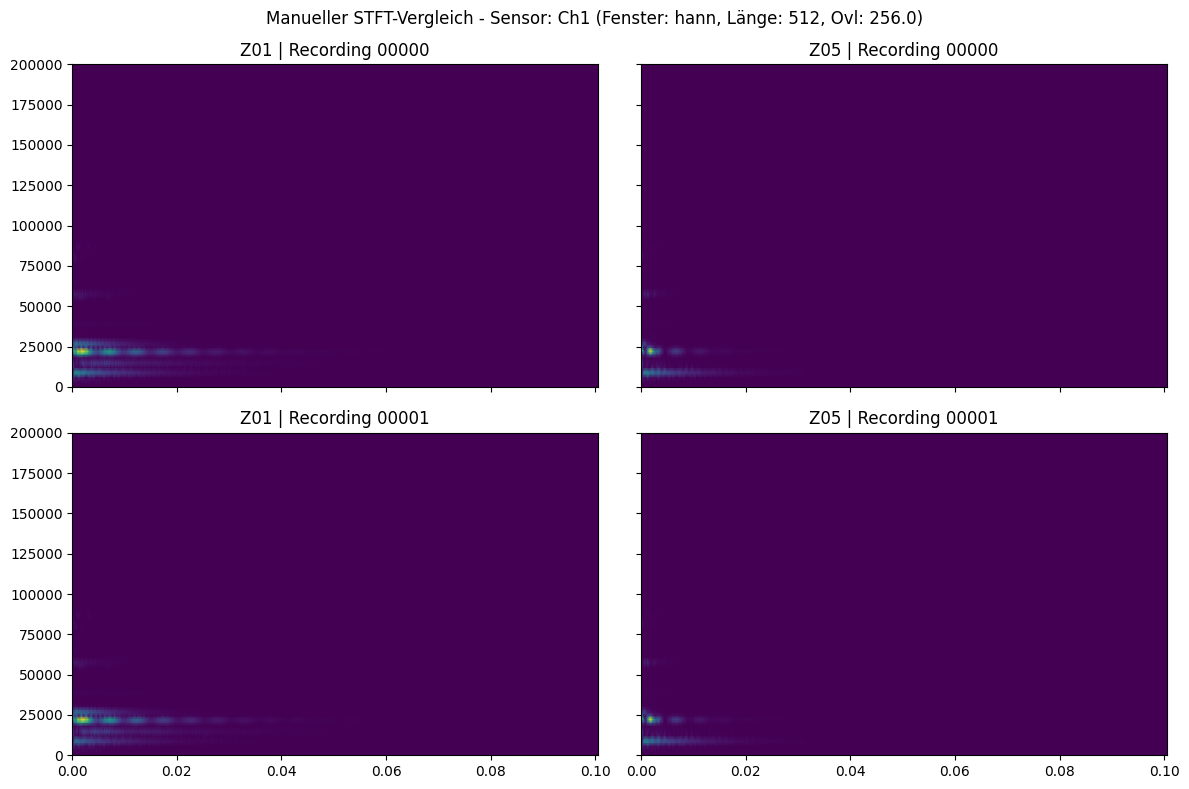

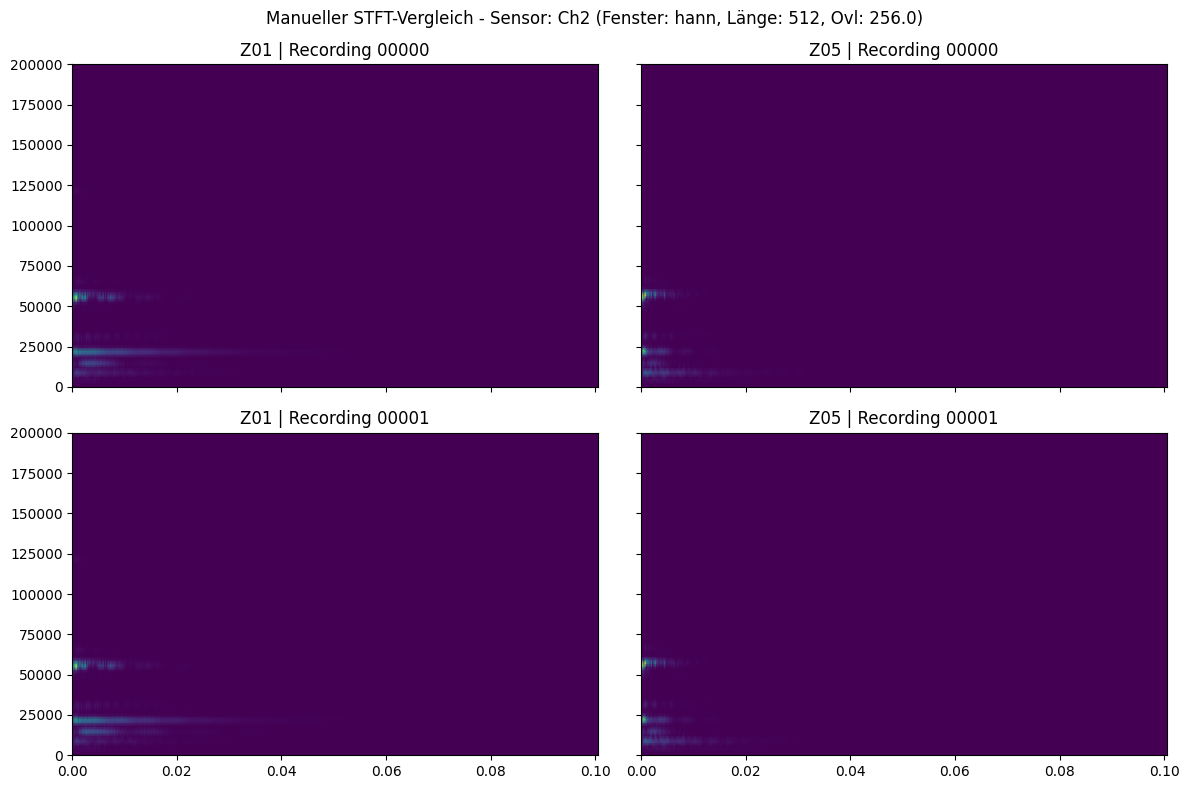

In [17]:
# Manuelle STFT-Parameter zum Testen
Window = 512
Overlap = Window * 0.5   # Percent of overlapping 
WinFunc = 'hann'
# WinFunc = 'hamming'
# WinFunc = 'blackman'
# WinFunc = 'boxcar'

for sid in ["Ch1", "Ch2"]:
  fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
  fig.suptitle(f"Manueller STFT-Vergleich - Sensor: {sid} (Fenster: {WinFunc}, Länge: {Window}, Ovl: {Overlap})")
  for i, rid in enumerate(["00000", "00001"]):
     for j, spc in enumerate(["Z01", "Z05"]):
         row = df[(df.rID == rid) & (df.spec == spc) & (df.sID == sid)].iloc[0]
         f, t, Zxx = calculate_stft(row.sig, row.fs, nperseg=Window, noverlap=Overlap, window=WinFunc)
         axes[i,j].pcolormesh(t, f, np.abs(Zxx)**1.7, shading='gouraud')
         axes[i,j].set_ylim(0, 200000)
         axes[i,j].set_title(f"{spc} | Recording {rid}")
  plt.tight_layout(); plt.show()

## 2.1 Visuelle Analyse:

Wahl der Fensterfunktion:
- 'hann': gute Ergebnisse, oft verschwommen aber unterschiede waren gut identifizierbar
- 'hamming': keine offensichtliche Unterschiede zu hann festgestellt
- 'blackman': keine offensichtliche Unterschiede zu hann festgestellt
- 'boxcar': sehr "dünne" signale, periodische veränderung und abklingen des Signals sind nicht mehr gut erkennbar

$\Rightarrow$ im weiteren Verlauf der Tests größtenteils 'hann' genutzt

Wahl der Fensterlänge: Mit Fensterlänge von 400 Messpunkten gestartet
- bei Verringerung der Fensterlänge (um 50 Einheiten; bis 200 getestet) wurden die Spektogramme "gestreckter" und kleine Unterschiede wurden schwerer zu erkennen.
- bei Erhöhung wurden die Signale zwar genauer, aber auch kleiner im Spekrogramm und somit auch schwehrer zu lesen.

$\Rightarrow$ Optimalwert bei ungefähr 500 - 600 $\Rightarrow$ 550 finaler Wert


Überlappung: Bei 50% gestartet.
- niedrigere Überlappung (bis 0 getestet in 10er schritten) macht periodische Änderungen in der Häufigkeit der Frequenzen etwas schlechter sichtbar.
- bei zu hoher Überlappung wird das Spektogramm ebenfalls etwas verschwommener -> Details gehen verloren

$\Rightarrow$ insgesamt sahen die Spektrogramme bei einer Überlappung von 50% am besten aus, Änderungen haben entweder den Detailgrad verschlechtert oder zu Informationsverlust geführt.

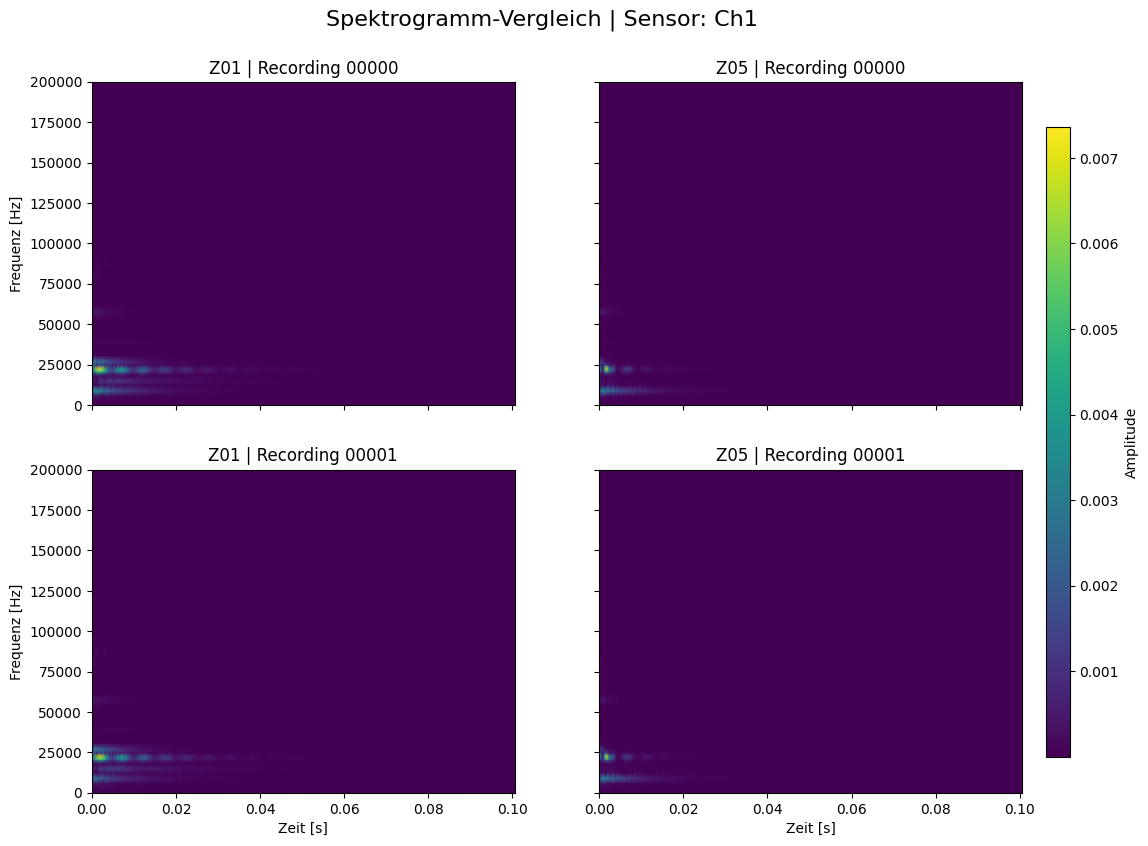
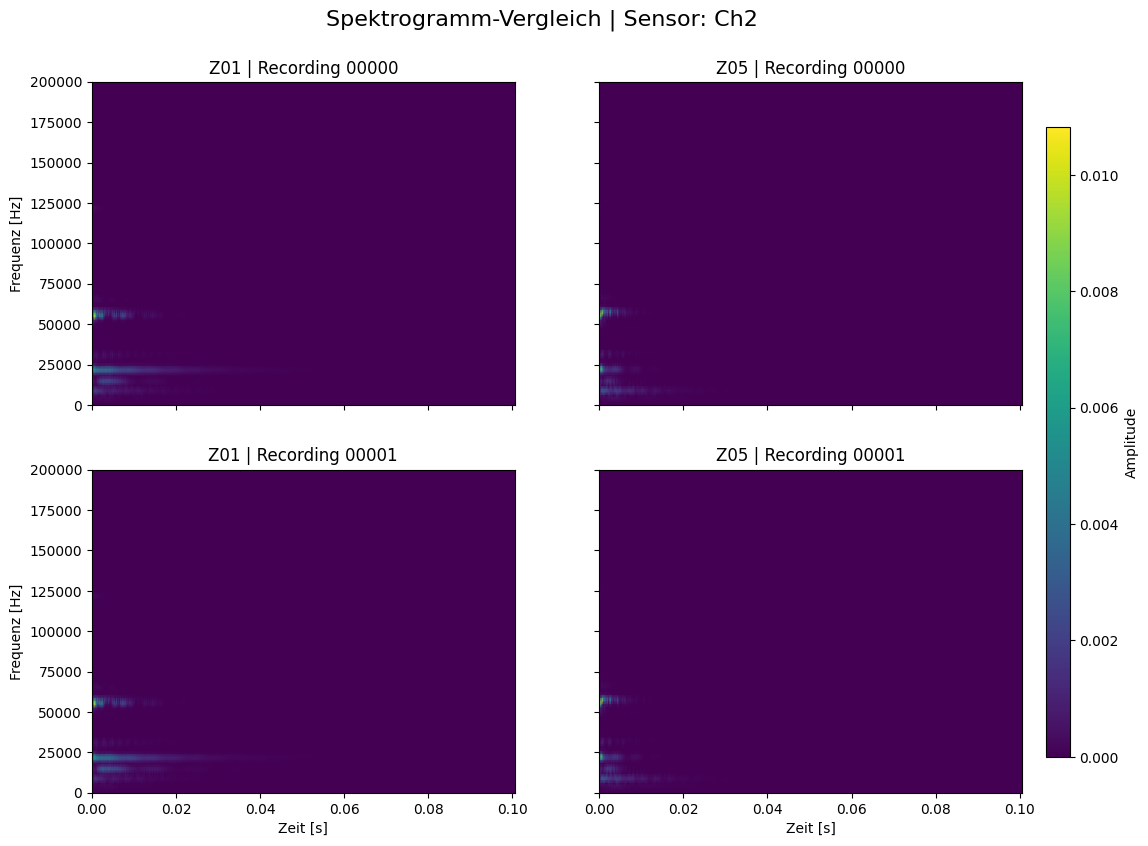

## 2.2 Mathematisches Vorgehen:

### Daten laden und Multi-Scale Parameter Optimierung

Diese Zelle lädt die Signaldaten und bestimmt automatisch die optimalen STFT-Parameter für zwei verschiedene Zahnräder:
1. **Kurzes Fenster (Short Window):** Optimiert für eine hohe zeitliche Auflösung, um impulsive Ereignisse (z.B. Zahnschäden, Stöße) zeitlich scharf zu lokalisieren.
2. **Langes Fenster (Long Window):** Optimiert für eine hohe Frequenzauflösung, um stationäre spektrale Merkmale (z.B. Seitenbänder, Harmonische) voneinander zu trennen.

### Mathematische Grundlagen und Konzepte:

**1. Kurzzeit-Fourier-Transformation (STFT):**
Im Gegensatz zur klassischen FFT, die das gesamte Signal in den Frequenzbereich transformiert und dabei alle Zeitinformationen verliert, verwendet die STFT ein **gleitendes Fenster** $w[n]$.
$$X(m, \omega) = \sum_{n=-\infty}^{\infty} x[n] w[n - m] e^{-j \omega n}$$
Das Signal wird in kleine Abschnitte unterteilt, die jeweils einzeln transformiert werden. So entsteht ein Abbild der Frequenzen über dem Zeitverlauf (Spektrogramm). Ein kurzes Fenster sieht zwar zeitlich scharf, verschmiert aber die Frequenzen (Unschärferelation).

**2. Energieprofil ($E[m]$):**
Das Energieprofil stellt die summierte Intensität aller Frequenzanteile pro Zeitpunkt $m$ dar:
$$E[m] = \sum_{k=0}^{K} |X(m, f_k)|$$
Es wandelt das komplexe Spektrogramm in einen eindimensionalen Zeitverlauf um, der die "momentane Energie" des Zahnrades beschreibt. Unregelmässigkeiten im Zahneingriff äussern sich hier als periodische Peaks.

**3. Diagnose-Kontrast (Clarity):**
Die Metrik findet die Parameter ($window-length$, $function$, $overlap$), die den energetischen Unterschied zwischen Zahnrad Z01 und Z05 maximieren. 
$$Clarity = |P(E_{Z01} > E_{Z05}) - 0.5| \cdot 200$$
Wir berechnen die Wahrscheinlichkeit $P$, dass die Energie von Z01 größer ist als die von Z05. 
- **0% Clarity:** Die Zahnräder sind energetisch identisch ($P=0.5$).
- **100% Clarity:** Die Zahnräder sind vollständig unterscheidbar ($P=1$ oder $P=0$).

**4. Fensterfunktionen:**
Wir untersuchen verschiedene Fenstertypen, um den optimalen Kompromiss zwischen Frequenzauflösung und Leckeffekt (Spectral Leakage) zu finden. Standardmässig werden Fenster wie **Hann** bevorzugt, da sie Geisterfrequenzen minimieren. Ein **Boxcar** (Rechteckfenster) wird nur gewählt, wenn es eine deutlich höhere Clarity ($>5\%$) liefert (nur in unserer Berechnung).

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import kurtosis
from dataframe_manager import DataFrameManager
from stft_processor import calculate_stft

data_path = '../data'
if not os.path.exists(data_path):
    print(f"Fehler: Datenordner nicht gefunden.")

manager = DataFrameManager(data_dir=data_path)
manager.load_signals()
df = manager.get_dataframe()
print(f"Erfolgreich {len(df)} Signale geladen.")

def find_best_windows(df, r_id='00000'):
    # Suchbereiche fuer beide Skalen
    nperseg_short = range(128, 513, 32)      
    nperseg_long = range(1024, 4097, 256)    
    overlap_ratios = [0.5, 0.75, 0.9]        
    windows = ["hann", "hamming", "blackman", "boxcar"]
    
    def optimize_scale(n_range):
        results = []
        for win in windows:
            for nps in n_range:
                for ratio in overlap_ratios:
                    nov = int(nps * ratio)
                    scale_contrast = []
                    for s_id in ['Ch1', 'Ch2']:
                        z01_q = df[(df['spec']=='Z01') & (df['sID'] == s_id) & (df['rID'] == r_id)]
                        z05_q = df[(df['spec']=='Z05') & (df['sID'] == s_id) & (df['rID'] == r_id)]
                        if z01_q.empty or z05_q.empty: continue
                        f, _, s1 = calculate_stft(z01_q.iloc[0]['sig'], z01_q.iloc[0]['fs'], nperseg=nps, noverlap=nov, window=win)
                        _, _, s5 = calculate_stft(z05_q.iloc[0]['sig'], z05_q.iloc[0]['fs'], nperseg=nps, noverlap=nov, window=win)
                        e1, e5 = np.sum(np.abs(s1), axis=0), np.sum(np.abs(s5), axis=0)
                        prob = np.mean(e1 > e5)
                        contrast = abs(prob - 0.5) * 200
                        scale_contrast.append(contrast)
                    if scale_contrast:
                        results.append({'nperseg': nps, 'window': win, 'noverlap': nov, 'clarity': np.mean(scale_contrast)})
        
        res_df = pd.DataFrame(results)
        # Auswahl-Logik: Bevorzuge Nicht-Boxcar, auBer Boxcar ist > 5% besser
        non_boxcar = res_df[res_df['window'] != 'boxcar'].sort_values('clarity', ascending=False)
        boxcar_only = res_df[res_df['window'] == 'boxcar'].sort_values('clarity', ascending=False)
        
        if not boxcar_only.empty and not non_boxcar.empty:
            if boxcar_only.iloc[0]['clarity'] > non_boxcar.iloc[0]['clarity'] + 5.0:
                return boxcar_only.iloc[0]
        return non_boxcar.iloc[0] if not non_boxcar.empty else boxcar_only.iloc[0]

    print("Suche optimale Parameter fuer Zeit-Aufloesung (Short Window)...")
    best_short = optimize_scale(nperseg_short)
    print("Suche optimale Parameter fuer Frequenz-Aufloesung (Long Window)...")
    best_long = optimize_scale(nperseg_long)
    return best_short, best_long

OPT_SHORT, OPT_LONG = find_best_windows(df)
print(f"\nErgebnis der Optimierung:")
print(f"Best Short: window-length={OPT_SHORT['nperseg']}, function={OPT_SHORT['window']}, overlap={OPT_SHORT['noverlap']}, Clarity={OPT_SHORT['clarity']:.2f}%")
print(f"Best Long:  window-length={OPT_LONG['nperseg']}, function={OPT_LONG['window']}, overlap={OPT_LONG['noverlap']}, Clarity={OPT_LONG['clarity']:.2f}%")

Y_FREQ_MAX, X_TIME_MAX = 200000, 0.1

Erfolgreich 12 Signale geladen.
Suche optimale Parameter fuer Zeit-Aufloesung (Short Window)...
Suche optimale Parameter fuer Frequenz-Aufloesung (Long Window)...

Ergebnis der Optimierung:
Best Short: window-length=512, function=hann, overlap=460, Clarity=98.06%
Best Long:  window-length=3584, function=hann, overlap=3225, Clarity=98.63%


# 3 Vergleich der Zahnräder & Identifikation des Defekts

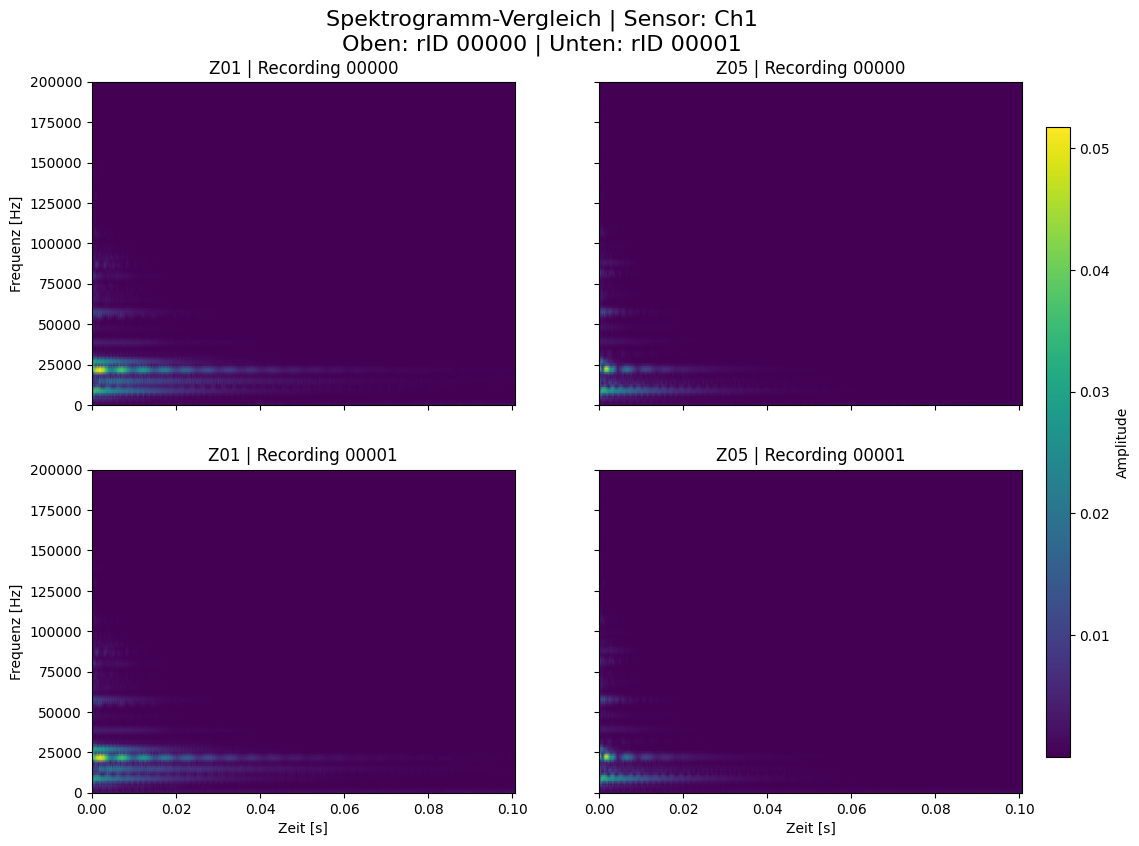

### $\Rightarrow$ Z05 ist sehr wahrscheinlich das Defekte Zahnrad

- Die Signalantwort von Z01 schwingt länger, dies lässt sich vorallem in Frequenzen von 0 - 25000 Hz sehen, jedoch auch bei ca. 55000 Hz

- Die Lücken zwischen den Perioden sind bei Z05 deutlich erkennbar und haben eine Amplitude von annähernd Null, Z01 hat deutlich sanftere Übergänge

### $\Rightarrow$ Z01 hat wahrscheinlich keine Schäden, da der Ton weich und Gleichmäßig im Metall abklingt

### $\Rightarrow$ Z05 hat wahrscheinlich Risse, Unförmigkeiten oder eine ungleichmäßige Dichte, was die erkennbaren Schwingungen schneller und weniger sanft abklingen lässt
